In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [6]:
def get_dog_kernels(size=5, sigma=2):
    k = size // 2
    y, x = np.ogrid[-k:k+1, -k:k+1]
    
    # Standard Gaussian
    gaussian = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # Derivatives
    gx = -(x / sigma**2) * gaussian
    gy = -(y / sigma**2) * gaussian
    
    # Normalize: Sum of absolute values to 1 for gradient consistency
    gx /= np.sum(np.abs(gx))
    gy /= np.sum(np.abs(gy))
    
    return gx, gy

gx_kernel, gy_kernel = get_dog_kernels()

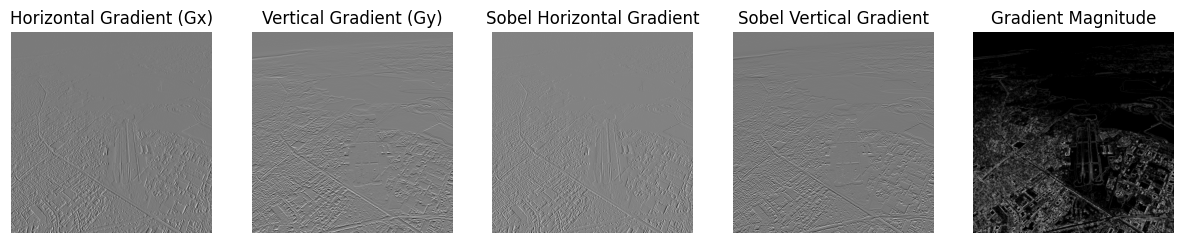

In [13]:

# Load image
img = cv2.imread('runway.png', 0)

# (d) Manual Convolution
grad_x_dog = cv2.filter2D(img, cv2.CV_64F, gx_kernel)
grad_y_dog = cv2.filter2D(img, cv2.CV_64F, gy_kernel)

# (e) OpenCV Sobel
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

# Calculate Magnitude: sqrt(Gx^2 + Gy^2)
magnitude = np.sqrt(grad_x_dog**2 + grad_y_dog**2)
magnitude = np.uint8(np.clip(magnitude, 0, 255))

# --- Visualization ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 5, 1); plt.imshow(grad_x_dog, cmap='gray'); plt.title('Horizontal Gradient (Gx)'); plt.axis('off')
plt.subplot(1, 5, 2); plt.imshow(grad_y_dog, cmap='gray'); plt.title('Vertical Gradient (Gy)'); plt.axis('off')
plt.subplot(1, 5, 3); plt.imshow(sobel_x, cmap='gray'); plt.title('Sobel Horizontal Gradient'); plt.axis('off')
plt.subplot(1, 5, 4); plt.imshow(sobel_y, cmap='gray'); plt.title('Sobel Vertical Gradient'); plt.axis('off')
plt.subplot(1, 5, 5); plt.imshow(magnitude, cmap='gray'); plt.title('Gradient Magnitude'); plt.axis('off')

plt.show()